In [1]:
import pandas as pd


In [2]:
# The TSV file  doesn't have a header row
df = pd.read_csv(
    "dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    names=["par_id", "art_id", "keyword", "countrycode", "text", "label"]
)

In [3]:
# Convert multi-class label to binary: 1 if label >= 2, else 0
df["binary_label"] = df["label"].apply(lambda x: 1 if x >= 2 else 0)


In [4]:
# Check shape and first few rows
print(df.shape)
df.head()


# Check label distribution
print(df["binary_label"].value_counts())

(10472, 7)
binary_label
0    9479
1     993
Name: count, dtype: int64


In [5]:
# Load train/dev splits
train_ids = pd.read_csv("train_semeval_parids-labels.csv")
dev_ids = pd.read_csv("dev_semeval_parids-labels.csv")

print(train_ids.head())
print(dev_ids.head())

   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]
   par_id                  label
0    4046  [1, 0, 0, 1, 0, 0, 0]
1    1279  [0, 1, 0, 0, 0, 0, 0]
2    8330  [0, 0, 1, 0, 0, 0, 0]
3    4063  [1, 0, 0, 1, 1, 1, 0]
4    4089  [1, 0, 0, 0, 0, 0, 0]


In [6]:
# Convert dev and train CSV par_ids to string sets (to match main df type)
train_pcl_ids = set(train_ids["par_id"].astype(str).str.strip())
dev_pcl_ids = set(dev_ids["par_id"].astype(str).str.strip())

# Split the main dataframe:
# Dev set = all paragraphs whose par_id appears in the dev CSV
# Train set = everything else (all paragraphs NOT in the dev CSV)
dev_df = df[df["par_id"].isin(dev_pcl_ids)].copy()
train_df = df[~df["par_id"].isin(dev_pcl_ids)].copy()

# Binarise the labels for subtask 1:
# Original labels are 0-4 scale
# 0 or 1 → Not PCL (0)
# 2, 3, or 4 → PCL (1)
train_df["binary_label"] = train_df["label"].apply(lambda x: 1 if x >= 2 else 0)
dev_df["binary_label"] = dev_df["label"].apply(lambda x: 1 if x >= 2 else 0)

# Sanity checks: print shapes and label distributions
print(f"Train: {train_df.shape}")
print(f"Dev: {dev_df.shape}")
print("\nTrain label distribution:")
print(train_df["binary_label"].value_counts())
print("\nDev label distribution:")
print(dev_df["binary_label"].value_counts())

Train: (8378, 7)
Dev: (2094, 7)

Train label distribution:
binary_label
0    7584
1     794
Name: count, dtype: int64

Dev label distribution:
binary_label
0    1895
1     199
Name: count, dtype: int64


# Class Distribution and Text Length Analysis ￼

In this section, we will perform some basic statistical profiling of the training data. \We first inspect the class distribution of the binary labels in the train set by plotting the number and percentage of samples in the “No PCL (0)” and “PCL (1)” classes, and computing the resulting imbalance ratio. Helping us understand how skewed our dataset is.

We then analyse text length at the paragraph level. For each example, we compute the word count and visualise the distributions separately for “No PCL” and “PCL” using histograms and a box plot. Finally, we report summary statistics (mean and median word counts per class) to see whether PCL paragraphs differ systematically in length compared to non‑PCL paragraphs.

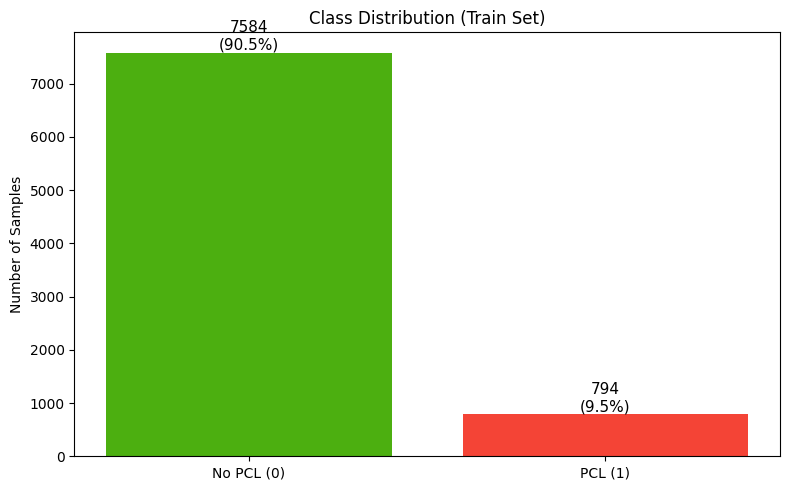

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special

# Create a single figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

# --- Plot: Class Distribution ---
counts = train_df["binary_label"].value_counts()
labels = ["No PCL (0)", "PCL (1)"]
colors = ["#4CAF10", "#F44436"]

bars = ax.bar(labels, [counts[0], counts[1]], color=colors)
ax.set_title("Class Distribution (Train Set)")
ax.set_ylabel("Number of Samples")

# Add count and percentage labels on bars
for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(train_df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        fontsize=11,
    )

plt.tight_layout()
plt.show()


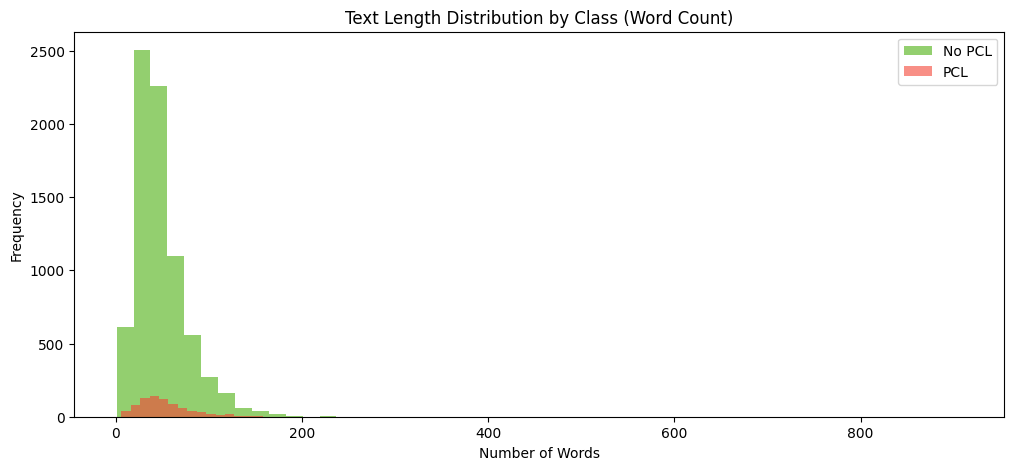

In [8]:
# --- Plot 2: Text Length Distribution by Class ---
fig, ax = plt.subplots(figsize=(12, 5))
train_df["text_length"] = train_df["text"].apply(lambda x: len(str(x).split()))
for label, color, name in zip([0, 1], colors, ["No PCL", "PCL"]):
    subset = train_df[train_df["binary_label"] == label]["text_length"]
    ax.hist(subset, bins=50, alpha=0.6, label=name, color=color)
ax.set_title("Text Length Distribution by Class (Word Count)")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Frequency")
ax.legend()


/tmp/ipykernel_392/3499273842.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["No PCL", "PCL"], patch_artist=True)


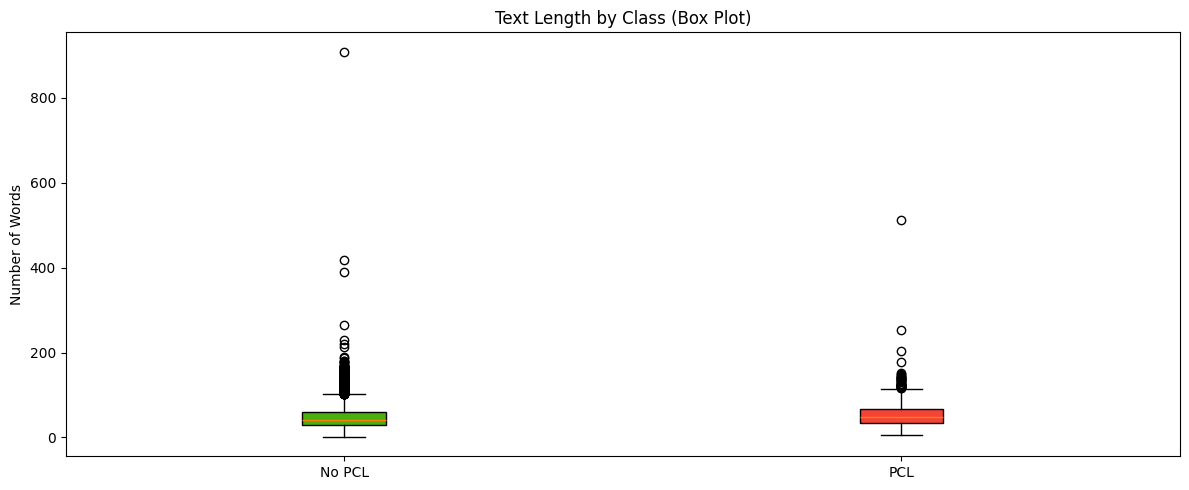

In [9]:
# --- Plot 3: Box Plot of Text Length by Class ---

fig, ax = plt.subplots(figsize=(12, 5))

data_to_plot = [
    train_df[train_df["binary_label"] == 0]["text_length"],
    train_df[train_df["binary_label"] == 1]["text_length"]
]
bp = ax.boxplot(data_to_plot, labels=["No PCL", "PCL"], patch_artist=True)
bp["boxes"][0].set_facecolor(colors[0])
bp["boxes"][1].set_facecolor(colors[1])
ax.set_title("Text Length by Class (Box Plot)")
ax.set_ylabel("Number of Words")

plt.tight_layout()
plt.savefig("eda1_class_distribution_and_length.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Print summary stats
print("\n--- Summary Statistics ---")
print(f"Total train samples: {len(train_df)}")
print(f"No PCL: {counts[0]} ({counts[0]/len(train_df)*100:.1f}%)")
print(f"PCL: {counts[1]} ({counts[1]/len(train_df)*100:.1f}%)")
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")
print(f"\nText length (words) - No PCL: mean={train_df[train_df['binary_label']==0]['text_length'].mean():.1f}, median={train_df[train_df['binary_label']==0]['text_length'].median():.1f}")
print(f"Text length (words) - PCL:    mean={train_df[train_df['binary_label']==1]['text_length'].mean():.1f}, median={train_df[train_df['binary_label']==1]['text_length'].median():.1f}")


--- Summary Statistics ---
Total train samples: 8378
No PCL: 7584 (90.5%)
PCL: 794 (9.5%)
Imbalance ratio: 9.6:1

Text length (words) - No PCL: mean=48.1, median=42.0
Text length (words) - PCL:    mean=53.5, median=47.0


## Analysis:
The training set exhibits a major class imbalance with a 9.6:1 ratio of no PCL : PCL. This means a naive classifier that always predicts No PCL, achieves a >90% accuracy whilst completely failing at the task. The text length distributions are prettye even with PCL being slighlty longer. Both classes showes slightly skewed text to the left, with majority of texts being under 100 words. This shows that doubling down on text length is not a worthy descriptive feature in our dataset.


 ## Impact:
The extreme class imbalance is our most critical finding and the one that affects us the most in our model. A fine-tuned classifier will be biased towards predicting the majority class, which might result in a poor recall for PCL. Accuracy therefore is not a valuable metric for this model. We must rely on the positive class F1-score as well as well the Macro-F1 scores. To address this, we might employ stratgeies such as class-weighted loss functions , oversampling the minority class (through NLP-specific data augmentation techniques). Since most texts are under 128 words we can use that as a reasonable starting point for tokenisation as that will capture 95% percentile of texts.

# EDA 2: N-gram Analysis — Comparing PCL vs No PCL


In this section, we analyze bigrams (two-word sequences) separately for the two classes to understand how language is used in patronising content as opposed to non-patronising content.

For each class, we will collect all training texts with that label and use a CountVectorizer and English stop-word removal to extract the most frequent bigrams. Then we plot the top bigrams for each class as bar charts showing how much each phrase was used.

This shows which expressions are more likely to be represented as PCL versus non-PCL and can provide a further intuition for later feature engineering or model interpretation,

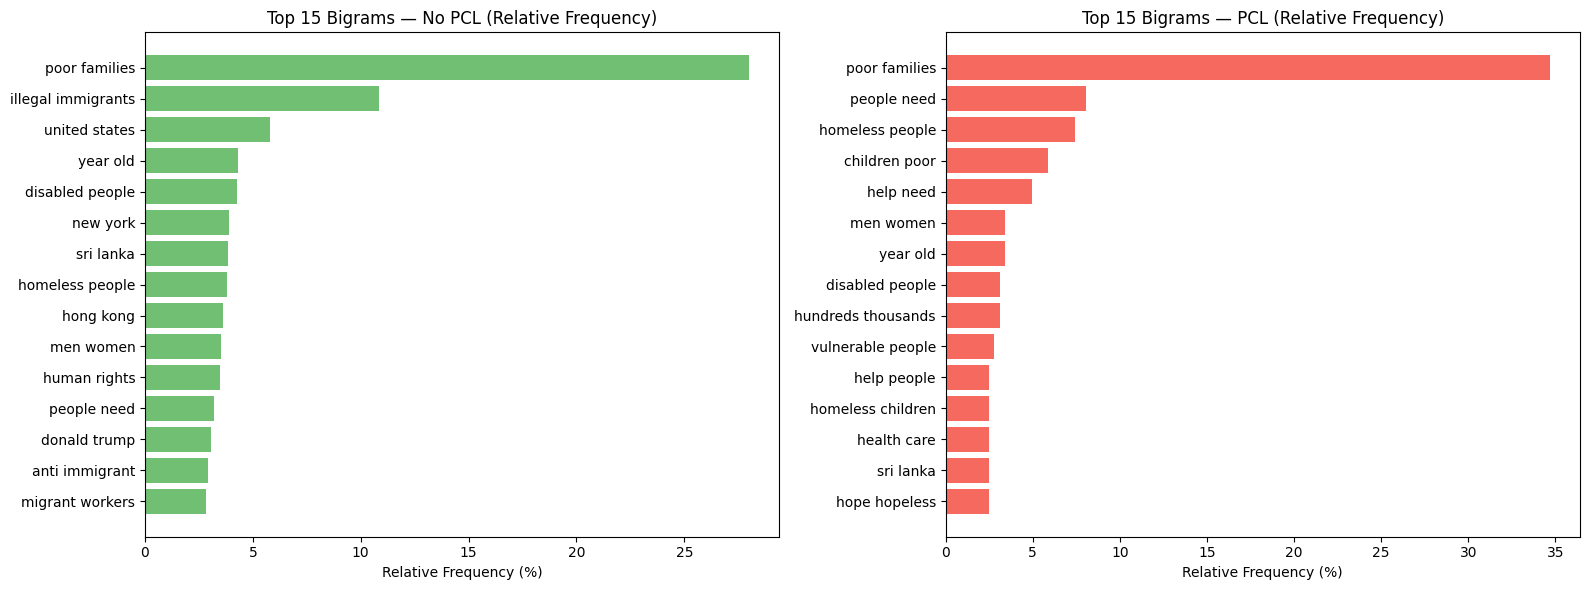

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
import re

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, name, color) in enumerate(zip([0, 1], ["No PCL", "PCL"], ["#4CAF50", "#F44336"])):
    # Get texts for this class, dropping any NaN values
    texts = train_df[train_df["binary_label"] == label]["text"].dropna().tolist()

    # Clean artifacts like &amp;, \n, extra whitespace
    texts = [re.sub(r'&\w+;|\n|\\n', ' ', str(t)).strip() for t in texts]

    # Extract bigrams, removing stop words
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=20)
    X = vectorizer.fit_transform(texts)

    # Use RELATIVE frequency (% of total bigrams in this class) to account for class imbalance
    total_bigrams = X.sum()
    freqs = (X.sum(axis=0).A1 / total_bigrams) * 100  # Convert to percentage
    bigrams = vectorizer.get_feature_names_out()
    top_idx = freqs.argsort()[::-1][:15]

    # Plot horizontal bar chart
    axes[idx].barh(range(len(top_idx)), freqs[top_idx][::-1], color=color, alpha=0.8)
    axes[idx].set_yticks(range(len(top_idx)))
    axes[idx].set_yticklabels([bigrams[i] for i in top_idx][::-1])
    axes[idx].set_title(f"Top 15 Bigrams — {name} (Relative Frequency)")
    axes[idx].set_xlabel("Relative Frequency (%)")

plt.tight_layout()
plt.savefig("eda2_bigram_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Analysis

The bigram analysis shows both overlaps and differences in the two classes.
"Poor families" dominate both classes, appearing as the top bigram for both, which is most likely because the dataset is built around news articles focussing on vulnerable and disadvantaged communities.

However the PCL class shows different secondary bigrams with phrases like "people need" "homeless people", "vulnerable people", "homeless children", "hope hopeless" which are all prominent in PCL class but less prominent in non-PCL. These bigrams reflect a paternalistic framing, where as reflected in the dataset, this is language that positions vulnerable groups as helpless and in need of saving. In contrast, the non-PCL  class features more factual, neutral bigrams such as "human rights", names of people and places and descriptions of people status which are geographic or political references typical of objective news reporting.


## Impact:
A significant overlap in the top words used in both PCL vs Non-PCL texts shows that a simple bag-of-words classifier would struggle to simply distinguish the two classes.Secondly, it also shows that patronising language is characterised by a specific rhetorical pattern of depicting subjects as helpless. It is characterized by a lexicon of "saviour" and "pity" biased words. Consequently, I will prioritize using a transformer-based model that can capture the contextual nuance of these phrases, as simple keywords like "poor families" appear in both classes and would lead to high false-positive rates. I will also ensure my preprocessing does not remove words like "need" or "help" as stop words, as they appear to be significant indicators of patronising tone.

# Model

We propose, as an upgrade to the baseline RoBERTa-base model, to use a fine-tuning pipeline based on the  DeBERTa-v3-base model. Its disentangled attention mechanism separately encoding positional information and content, allows us to enable stronger modelling of the subtle tonal features that differentiate PCL text from non-PCL text, a key challenge identified in our EDA.

Our pipeline consists of 1: a class-weighted Cross-Entropy Loss. This is because our EDA revealed a severe 9.6:1 class imbalance. To prevent the model from defaulting to the majority class, we apply class-weighted cross-entropy loss, directly penalising missed PCL examples during training without altering the data distribution or risking overfitting through oversampling non-PCL texts.

Rather than using a default 0.5 decision boundary we sweep classification thresholds on an Internal Validation set and select the threshold set that maximises F1-score, which is 20% of the original train set. This is to reduce data leakage. It also directly optimises the evaluation metric and makes it impactful for tasks where the subtle features make it difficult to reach a boundary of 0.5.

We add an auxiliary classification head for the 7 PCL subcategory labels provided in the dataset. This forces the shared encoder to learn fine-grained distinctions between types of patronising language, producing richer representations for the primary binary task.

We used DeBERTa over RoBERTa because although PCL and Non-PCL texts share the same sort of topical language, they differ in framing and tone. DeBERTa is better suited to capture those pragmatic differences.  We also used a weighted loss because we predict the baselines achieves a low F1 because it under-predicts the minority class. This allows it to introduce a solution without additional hyperameters or overfitting or losing training data.

We also use the 7 PCL subcategories to encode the specific rhetorical devices behind the patronising language. It is essentially free data that people are not using to train the model and so the model is encouraged to learn the linguistic mechanisms of condenscation instead of surface-level features.

We expect this pipeline to achieve a positive-class F1 score of approximately 0.60 on the test set, representing a significant improvement over the RoBERTa-base baseline of 0.49. The gains are expected to come from stronger contextual representations (DeBERTa), imbalance-aware optimisation (weighted loss + threshold tuning), and richer supervision signal (multi-task subcategory learning).

# Install Dependencies

In [12]:
# !pip install transformers datasets accelerate scikit-learn


In [13]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, precision_recall_curve



In [14]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


# Load Data and Split

In [15]:
import pandas as pd
import ast
from sklearn.model_selection import train_test_split

# --- Load train/dev split files ---
train_ids = pd.read_csv("train_semeval_parids-labels.csv")
dev_ids = pd.read_csv("dev_semeval_parids-labels.csv")
train_ids["par_id"] = train_ids["par_id"].astype(str).str.strip()
dev_ids["par_id"] = dev_ids["par_id"].astype(str).str.strip()

# --- Split main dataset into train and official dev ---
dev_pcl_ids = set(dev_ids["par_id"])
dev_df = df[df["par_id"].isin(dev_pcl_ids)].copy()
train_full_df = df[~df["par_id"].isin(dev_pcl_ids)].copy()

# --- Binarise labels (0-1 → No PCL, 2-4 → PCL) ---
train_full_df["binary_label"] = train_full_df["label"].apply(lambda x: 1 if x >= 2 else 0)
dev_df["binary_label"] = dev_df["label"].apply(lambda x: 1 if x >= 2 else 0)

# Build lookup: par_id → 7-dim subcategory vector
subcategory_lookup = {}
for ids_df in [train_ids, dev_ids]:
    for _, row in ids_df.iterrows():
        par_id = str(row["par_id"]).strip()
        subcat = ast.literal_eval(row["label"])
        subcategory_lookup[par_id] = subcat

# Add subcategory labels to dataframes
# Non-PCL examples get [0, 0, 0, 0, 0, 0, 0]
default_subcat = [0, 0, 0, 0, 0, 0, 0]

train_full_df["subcategory"] = train_full_df["par_id"].apply(
    lambda x: subcategory_lookup.get(x, default_subcat)
)
dev_df["subcategory"] = dev_df["par_id"].apply(
    lambda x: subcategory_lookup.get(x, default_subcat)
)

print(f"Subcategory column added. Sample:")
print(train_full_df[["par_id", "binary_label", "subcategory"]].head())

# --- Create internal validation set from training data ---
# This is used for threshold tuning (NOT the official dev set)
train_split, val_split = train_test_split(
    train_full_df,
    test_size=0.05,
    random_state=42,
    stratify=train_full_df["binary_label"]
)

# ==========================================
# --- ADDED: Oversample the minority class ---
# ==========================================
def oversample_minority_class(df_to_oversample, factor=2.5):
    """Oversamples the PCL class (1) by a specific factor."""
    no_pcl = df_to_oversample[df_to_oversample["binary_label"] == 0]
    pcl = df_to_oversample[df_to_oversample["binary_label"] == 1]

    n_extra = int(len(pcl) * (factor - 1))
    if n_extra > 0:
        extra = pcl.sample(n=n_extra, replace=True, random_state=42)
        # Concatenate and shuffle
        df_to_oversample = pd.concat([df_to_oversample, extra], ignore_index=True).sample(frac=1, random_state=42)
    return df_to_oversample.reset_index(drop=True)

# IMPORTANT: Only apply oversampling to the TRAIN split!
train_split = oversample_minority_class(train_split, factor=2.5)


# --- Print final stats ---
print(f"\nTrain split (AFTER oversampling): {train_split.shape}")
print(f"Val split (for threshold tuning): {val_split.shape}")
print(f"Official dev set: {dev_df.shape}")

print(f"\nTrain labels (oversampled):\n{train_split['binary_label'].value_counts()}")
print(f"\nVal labels (original distribution):\n{val_split['binary_label'].value_counts()}")
print(f"\nDev labels (original distribution):\n{dev_df['binary_label'].value_counts()}")

print("\nColumns in train_split:")
print(train_split.columns.tolist())

Subcategory column added. Sample:
                                              par_id  binary_label  \
0  ----------------------------------------------...             0   
1  The Don’t Patronize Me! dataset has been creat...             0   
2  ----------------------------------------------...             0   
3                                                  1             0   
4                                                  2             0   

             subcategory  
0  [0, 0, 0, 0, 0, 0, 0]  
1  [0, 0, 0, 0, 0, 0, 0]  
2  [0, 0, 0, 0, 0, 0, 0]  
3  [0, 0, 0, 0, 0, 0, 0]  
4  [0, 0, 0, 0, 0, 0, 0]  

Train split (AFTER oversampling): (9090, 8)
Val split (for threshold tuning): (419, 8)
Official dev set: (2094, 8)

Train labels (oversampled):
binary_label
0    7205
1    1885
Name: count, dtype: int64

Val labels (original distribution):
binary_label
0    379
1     40
Name: count, dtype: int64

Dev labels (original distribution):
binary_label
0    1895
1     199
Name: count, dt

# Dataset Class and Tokenizer


In [16]:
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [17]:

class PCLMultiTaskDataset(Dataset):
    """Dataset that returns both binary and subcategory labels."""

    def __init__(self, texts, binary_labels, subcategory_labels, tokenizer, max_length=128):
        self.texts = texts
        self.binary_labels = binary_labels
        self.subcategory_labels = subcategory_labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }

        if "token_type_ids" in encoding:
            item["token_type_ids"] = encoding["token_type_ids"].squeeze(0)

        # Binary label (main task)
        item["labels"] = torch.tensor(self.binary_labels[idx], dtype=torch.long)

        # Subcategory label (auxiliary task) — 7-dim multi-label vector
        item["subcategory_labels"] = torch.tensor(
            self.subcategory_labels[idx], dtype=torch.float
        )

        return item


In [18]:
# --- Create datasets ---
train_dataset = PCLMultiTaskDataset(
    texts=train_split["text"].tolist(),
    binary_labels=train_split["binary_label"].tolist(),
    subcategory_labels=train_split["subcategory"].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = PCLMultiTaskDataset(
    texts=val_split["text"].tolist(),
    binary_labels=val_split["binary_label"].tolist(),
    subcategory_labels=val_split["subcategory"].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

dev_dataset = PCLMultiTaskDataset(
    texts=dev_df["text"].tolist(),
    binary_labels=dev_df["binary_label"].tolist(),
    subcategory_labels=dev_df["subcategory"].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

In [19]:
print(f"\nDataset sizes — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Dev: {len(dev_dataset)}")



Dataset sizes — Train: 9090, Val: 419, Dev: 2094


# Model DeBERTa

In [20]:
class MultiTaskDeBERTa(nn.Module):
    def __init__(self, model_name, class_weights=None, lambda_aux=0.5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.encoder.config.hidden_size

        self.binary_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 2)
        )
        self.subcategory_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 7)
        )
        self.lambda_aux = lambda_aux

        # Store class weights as a buffer so they automatically move to the GPU
        # and cast to the correct dtype alongside the model
        if class_weights is not None:
            self.register_buffer("class_weights", torch.tensor(class_weights, dtype=torch.float))
        else:
            self.class_weights = None

    def forward(self, input_ids, attention_mask, token_type_ids=None,
                labels=None, subcategory_labels=None, **kwargs):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        cls_output = outputs.last_hidden_state[:, 0, :]

        # FIX 1: Force the input to match the linear head's dtype to prevent the Half/Float crash
        cls_output = cls_output.to(self.binary_head[1].weight.dtype)

        binary_logits = self.binary_head(cls_output)
        subcategory_logits = self.subcategory_head(cls_output)


        loss = None
        if labels is not None:
            # The model now handles the weighted loss natively
            binary_loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
            binary_loss = binary_loss_fn(binary_logits, labels)

            if subcategory_labels is not None:
                subcategory_loss_fn = nn.BCEWithLogitsLoss(reduction="none")


                subcategory_labels = subcategory_labels.to(subcategory_logits.dtype)
                subcat_loss_all = subcategory_loss_fn(subcategory_logits, subcategory_labels)


                mask = (subcategory_labels.sum(dim=1) > 0).to(subcat_loss_all.dtype).unsqueeze(1)
                subcat_loss_masked = (subcat_loss_all * mask).sum() / (mask.sum() * 7 + 1e-8)

                loss = binary_loss + self.lambda_aux * subcat_loss_masked
            else:
                loss = binary_loss

        return {"loss": loss, "logits": binary_logits}

# Custom Weighted Trainer

In [21]:
class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
      labels = inputs.pop("labels", None)
      subcategory_labels = inputs.pop("subcategory_labels", None)

      # Debug — run for just a few steps then remove
      if not hasattr(self, '_debug_count'):
          self._debug_count = 0
      if self._debug_count < 3:
          print(f"DEBUG: labels is None? {labels is None}, subcat is None? {subcategory_labels is None}")
          self._debug_count += 1

      outputs = model(**inputs, labels=labels, subcategory_labels=subcategory_labels)
      loss = outputs["loss"]
      return (loss, outputs) if return_outputs else loss
    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)

        labels = inputs.pop("labels", None)
        subcategory_labels = inputs.pop("subcategory_labels", None)

        with torch.no_grad():
            outputs = model(**inputs, labels=labels, subcategory_labels=subcategory_labels)
            loss = outputs["loss"]
            logits = outputs["logits"]

        if prediction_loss_only:
            return (loss, None, None)

        return (loss, logits, labels)

In [22]:
n_neg = (train_split["binary_label"] == 0).sum()
n_pos = (train_split["binary_label"] == 1).sum()
total = n_neg + n_pos
weight_neg = total / (2 * n_neg)
weight_pos = total / (2 * n_pos)
class_weights = [weight_neg, weight_pos]

print(f"\nClass weights — No PCL: {weight_neg:.4f}, PCL: {weight_pos:.4f}")
print(f"(PCL weighted {weight_pos/weight_neg:.1f}x more)")


Class weights — No PCL: 0.6308, PCL: 2.4111
(PCL weighted 3.8x more)


In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # labels is a tuple: (binary_labels, subcategory_labels)
    if isinstance(labels, (list, tuple)):
        labels = labels[0]
    probs = scipy.special.softmax(logits, axis=1)
    preds = (probs[:, 1] >= 0.5).astype(int)
    return {
        "f1_positive": f1_score(labels, preds, pos_label=1),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

In [24]:
model = MultiTaskDeBERTa(MODEL_NAME, class_weights=class_weights, lambda_aux=0.5)
model.to(device)

training_args = TrainingArguments(
    output_dir="./pcl_model_output",

    # Hyperparameters
    num_train_epochs=14,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # Mixed precision
    fp16=False,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_positive",
    greater_is_better=True,

    # Logging
    logging_dir="./logs",
    logging_steps=50,

    # Save space
    save_total_limit=2,

    # Reproducibility
    seed=42,
)

trainer = MultiTaskTrainer(
    # REMOVE this line: class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.

In [25]:
print("=" * 60)
print("Starting multi-task training...")
print("=" * 60)

trainer.train()

print("\nTraining complete!")


Starting multi-task training...
DEBUG: labels is None? False, subcat is None? False


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,F1 Positive,F1 Macro
1,0.782610,1.216069,0.305882,0.501140
2,0.651527,0.705599,0.444444,0.660178
3,0.509745,0.701177,0.485714,0.691281
4,0.415196,0.729226,0.597938,0.772653
5,0.309341,1.014435,0.560748,0.748226
6,0.233834,1.007416,0.507463,0.706856


DEBUG: labels is None? False, subcat is None? False
DEBUG: labels is None? False, subcat is None? False

Training complete!


In [26]:

print("=" * 60)
print("Threshold tuning on internal validation set...")
print("=" * 60)

val_output = trainer.predict(val_dataset)
val_logits = val_output.predictions
val_probs = torch.softmax(torch.tensor(val_logits), dim=-1).numpy()[:, 1]
val_labels = val_split["binary_label"].values

best_threshold = 0.5
best_f1 = 0.0
threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    preds = (val_probs >= threshold).astype(int)
    f1 = f1_score(val_labels, preds, pos_label=1)
    threshold_results.append({"threshold": threshold, "f1": f1})
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold:.2f}")
print(f"Best F1 (positive class) on val set: {best_f1:.4f}")


Threshold tuning on internal validation set...



Best threshold: 0.91
Best F1 (positive class) on val set: 0.6118


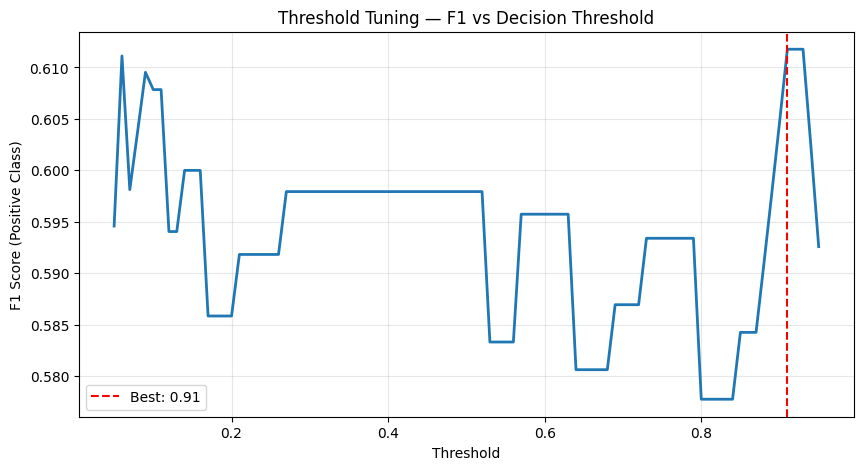

In [27]:
# Plot threshold vs F1
import matplotlib.pyplot as plt
thresh_df = pd.DataFrame(threshold_results)
plt.figure(figsize=(10, 5))
plt.plot(thresh_df["threshold"], thresh_df["f1"], linewidth=2)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best: {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Positive Class)")
plt.title("Threshold Tuning — F1 vs Decision Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
print("=" * 60)
print("Evaluating on official dev set with tuned threshold...")
print("=" * 60)

dev_output = trainer.predict(dev_dataset)
dev_logits = dev_output.predictions
dev_probs = torch.softmax(torch.tensor(dev_logits), dim=-1).numpy()[:, 1]
dev_labels = dev_df["binary_label"].values

dev_preds = (dev_probs >= 0.5).astype(int)
dev_f1 = f1_score(dev_labels, dev_preds, pos_label=1)

print(f"\nOfficial Dev Set F1 (positive class): {dev_f1:.4f}")
print(f"(Baseline to beat: 0.48)")
print(f"\nClassification report:")
print(classification_report(dev_labels, dev_preds, target_names=["No PCL", "PCL"]))


Evaluating on official dev set with tuned threshold...



Official Dev Set F1 (positive class): 0.5202
(Baseline to beat: 0.48)

Classification report:
              precision    recall  f1-score   support

      No PCL       0.96      0.93      0.94      1895
         PCL       0.47      0.58      0.52       199

    accuracy                           0.90      2094
   macro avg       0.71      0.76      0.73      2094
weighted avg       0.91      0.90      0.90      2094



In [30]:
# --- dev.txt ---
with open("dev.txt", "w") as f:
    for pred in dev_preds:
        f.write(f"{pred}\n")
print(f"dev.txt saved ({len(dev_preds)} predictions)")


test_df = pd.read_csv(
    "task4_test.tsv", sep="\t", header=None,
    names=["par_id", "art_id", "keyword", "countrycode", "text"]
)

test_dataset = PCLMultiTaskDataset(
    texts=test_df["text"].tolist(),
    binary_labels=[0] * len(test_df),        # dummy labels
    subcategory_labels=[[0]*7] * len(test_df), # dummy subcategories
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

with open("test.txt", "w") as f:
    for pred in test_preds:
        f.write(f"{pred}\n")
print(f"test.txt saved ({len(test_preds)} predictions)")


dev.txt saved (2094 predictions)


test.txt saved (3832 predictions)


In [31]:
# Save full model state dict + config for reproducibility
torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "lambda_aux": 0.5,
    "best_threshold": best_threshold,
    "class_weights": class_weights,
    "max_length": MAX_LENGTH,
}, "./BestModel/model_checkpoint.pt")

tokenizer.save_pretrained("./BestModel")

print(f"\nModel saved to ./BestModel")
print("\n" + "=" * 60)
print("DONE! Summary:")
print(f"  Model: {MODEL_NAME} (multi-task)")
print(f"  Auxiliary task: 7 PCL subcategories (lambda=0.5)")
print(f"  Best threshold: {best_threshold:.2f}")
print(f"  Val F1 (internal): {best_f1:.4f}")
print(f"  Dev F1 (official): {dev_f1:.4f}")
print(f"  Baseline F1: 0.48")
print("=" * 60)


Model saved to ./BestModel

DONE! Summary:
  Model: microsoft/deberta-v3-base (multi-task)
  Auxiliary task: 7 PCL subcategories (lambda=0.5)
  Best threshold: 0.91
  Val F1 (internal): 0.6118
  Dev F1 (official): 0.5202
  Baseline F1: 0.48
